# Targets and weighting in TorchRef

A TorchRef refinement is driven by a `LossState` that holds a collection of named **targets** (X-ray, geometry, ADP, ...) and a set of **weights**. The total loss is the weighted sum of target outputs; gradients flow through autograd into the model parameters.

This notebook covers:

1. listing and inspecting the standard targets,
2. evaluating the loss breakdown and the offset-based weighting that controls overfitting,
3. comparing the four X-ray target modes (Bhattacharyya / ML / LS / Gaussian),
4. measuring per-target cost on CPU and GPU,
5. writing custom targets,
6. driving an optimizer directly from a `LossState`,
7. a worked example: building a difference-refinement target from scratch,
8. inspecting metrics during refinement,
9. assembling a `Refinement` from pre-built components.

In [ ]:
# Colab setup - skip if running locally
# !pip install torchref
# !wget -q https://raw.githubusercontent.com/HatPdotS/TorchRef/main/example_notebooks/1DAW.pdb
# !wget -q https://raw.githubusercontent.com/HatPdotS/TorchRef/main/example_notebooks/1DAW.mtz

In [1]:
import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from torchref import ROOT_TORCHREF, LBFGSRefinement

if os.path.exists('./1DAW.mtz'):
    mtz_file = './1DAW.mtz'
    pdb_file = './1DAW.pdb'
else:
    mtz_file = f'{ROOT_TORCHREF}/example_notebooks/1DAW.mtz'
    pdb_file = f'{ROOT_TORCHREF}/example_notebooks/1DAW.pdb'

refinement = LBFGSRefinement(data_file=mtz_file, pdb=pdb_file)

/tmp/ipykernel_1442426/1062715871.py:8: UserWarning: TorchRef auto-configured 4 threads. Set TORCHREF_NUM_THREADS to override.
  from torchref import ROOT_TORCHREF, LBFGSRefinement


FrenchWilsonModule initialized:
  Reflections: 23356
  Resolution: 2.05 - 69.56 Å
  Space group: SpaceGroup('C2', number=5, n_ops=4)
  Centric: 1125 (4.8%)
found nan F values:  0
found nan F_sigma values:  0
Suspicious sigma detection: 0/23356 (0.00%) reflections flagged
LINK records: parsed 14, skipped 0 symmetry-mate, 0 malformed
Loaded 3051 atoms
Initialized ScalerBase with 10 bins.
Building restraints...
Found 109 link definitions
Built 328 peptide bond restraints
Built 997 peptide angle restraints
Built 328 peptide plane restraints
Built 14 LINK bond restraints

Building VDW (non-bonded) restraints...
  Symmetry expansion: 28 valid (symop, offset) combos
  Grid: [23, 9, 7], 1181/1449 cells occupied, max 216 entries/cell
  Built 59647 VDW restraints, 5183 symmetry contacts
  Hydrogen topology: 2708 riding H atoms
  H candidate pairs: 127751 (29548 H-H, 98203 H-heavy, 8022 symmetry)
Restraints Summary (New Implementation)
CIF file: None
Residue types in dictionary: 21

INTRA-RESIDUE

## 1. Registered targets

Names are hierarchical, separated by `/`. The first component is the **group** (`xray`, `geometry`, `adp`); group-level weights multiply every target inside the group, so you can rescale all geometry restraints in one call to `set_weight('geometry', ...)`.

In [2]:
loss_state = refinement.complete_loss_state()

print('Registered targets')
print('=' * 50)
groups = defaultdict(list)
for name in loss_state.targets.keys():
    parts = name.split('/', 1)
    group = parts[0] if len(parts) > 1 else 'root'
    comp = parts[1] if len(parts) > 1 else parts[0]
    groups[group].append(comp)

for group, components in groups.items():
    print(f'\n{group.upper()}')
    for c in components:
        print(f'  - {c}')

Registered targets

ROOT
  - xray

GEOMETRY
  - bond
  - angle
  - torsion
  - planarity
  - chiral
  - nonbonded
  - ramachandran

ADP
  - simu
  - locality
  - KL
  - scaler_U
  - scaler_log_scale


## 2. Loss breakdown and offset weighting

`loss_state.aggregate()` evaluates every target, multiplies by its weight, and returns the total loss. `get_breakdown()` returns the per-target loss / weight / weighted contribution; `get_group_totals()` sums weighted contributions inside each group.

Weighting is the lever that stops the refinement from overfitting. TorchRef's default scheme is **target-offset weighting** (`ComponentWeighting`): each regularisation target has a desired loss value, and the weight is set so that the current loss is pulled towards that target value. Geometry restraints are held tight while the X-ray residual is far from its target; as the model improves, the X-ray weight rises and the geometry weights relax. The X-ray term is weighed down substantially relative to geometry -- that is what stops the model from chasing noise.

In [3]:
def print_breakdown(state):
    total = state.aggregate().item()
    breakdown = state.get_breakdown()
    print(f"{'Target':<35} {'Loss':>12} {'Weight':>10} {'Weighted':>12}")
    print('-' * 71)
    for group, components in breakdown.items():
        print(f'[{group}]')
        for comp, v in components.items():
            print(f"  {comp:<33} {v['loss']:>12.4f} {v['weight']:>10.4f} {v['weighted']:>12.4f}")
    print('-' * 71)
    print(f"{'TOTAL':<35} {'':<12} {'':<10} {total:>12.4f}")

print_breakdown(loss_state)

print('\nGroup totals (weighted):')
for group, total in loss_state.get_group_totals().items():
    print(f'  {group:<15s} {total:>12.4f}')

Target                                      Loss     Weight     Weighted
-----------------------------------------------------------------------
[root]
  xray                                69316.0469     1.0000   69316.0469
[geometry]
  bond                                -6334.2349     1.3165   -8339.2783
  angle                               -3940.8015     1.3165   -5188.2256
  torsion                               335.0010     1.3165     441.0424
  planarity                           -5973.6807     1.3165   -7864.5938
  chiral                               -201.8472     1.3165    -265.7400
  nonbonded                          -45406.3320     1.3165  -59779.2852
  ramachandran                          414.9731     1.3165     546.3290
[adp]
  simu                                 5423.8457     1.3165    7140.7139
  locality                             6598.1929     1.3165    8686.7900
  KL                                      0.3759     1.3165       0.4949
  scaler_U                  

## 3. Comparing X-ray target modes

Four X-ray targets are available:

| mode | what it does |
|---|---|
| `gaussian`      | Gaussian likelihood on F_obs  - F_calc, sigma weighted. |
| `ls`            | Plain least squares on F_obs - F_calc. |
| `ml`            | Standard maximum likelihood with rcie distribution. |
| `bhattacharyya` | Bhattacharyya distance between observed and model amplitude distributions; the default in `LBFGSRefinement`. |

Below we run one macro cycle in each mode, starting from the same shaken model, and compare the final R-factors.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modes = ['gaussian', 'ls', 'ml', 'bhattacharyya']
results = []

for mode in modes:
    # Build on the target device from the start; .to(device) after construction
    # can leave some internal buffers behind on CPU.
    ref = LBFGSRefinement(
        data_file=mtz_file, pdb=pdb_file,
        target_mode=mode, device=device, verbose=0,
    )
    ref.model.shake_coords(0.1)  # identical perturbation magnitude per mode
    rw0, rf0 = ref.get_rfactor()
    t0 = time.perf_counter()
    ref.refine(macro_cycles=1)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    rw, rf = ref.get_rfactor()
    results.append({
        'mode': mode,
        'Rwork (start)': rw0, 'Rfree (start)': rf0,
        'Rwork (end)': rw,   'Rfree (end)': rf,
        'cycle time [s]': dt,
    })

df_targets = pd.DataFrame(results)
df_targets

Found 109 link definitions
Initializing TotalGeometryTarget with component targets...
Initializing TotalADPTarget with component targets...
Found 109 link definitions
Initializing TotalGeometryTarget with component targets...
Initializing TotalADPTarget with component targets...
Found 109 link definitions
Initializing TotalGeometryTarget with component targets...
Initializing TotalADPTarget with component targets...
Found 109 link definitions
Initializing TotalGeometryTarget with component targets...
Initializing TotalADPTarget with component targets...


,mode,Rwork (start),Rfree (start),Rwork (end),Rfree (end),cycle time [s]
0,gaussian,0.231810,0.290459,0.197717,0.282955,3.724092
1,ls,0.234708,0.284388,0.197909,0.280014,2.835201
2,ml,0.233527,0.292326,0.192785,0.281126,4.430924
3,bhattacharyya,0.234729,0.288957,0.209550,0.276758,3.972727


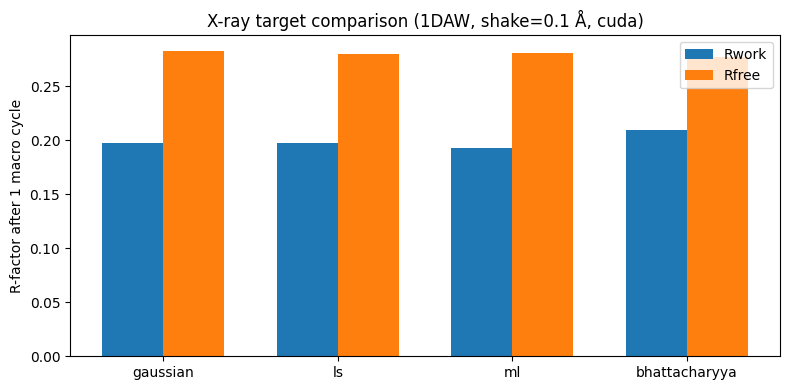

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(df_targets))
width = 0.35
ax.bar([i - width/2 for i in x], df_targets['Rwork (end)'], width, label='Rwork')
ax.bar([i + width/2 for i in x], df_targets['Rfree (end)'], width, label='Rfree')
ax.set_xticks(list(x))
ax.set_xticklabels(df_targets['mode'])
ax.set_ylabel('R-factor after 1 macro cycle')
ax.set_title(f'X-ray target comparison (1DAW, shake=0.1 Å, {device.type})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Per-target timing

Total refinement time is dominated by the X-ray target: it requires a fresh structure-factor calculation per call, while geometry and ADP terms operate directly on parameter tensors. Move the refinement to GPU and the relative cost shifts -- SF calculation parallelises nicely but the small geometry kernels do not, so launch overhead bites.

We build a fresh refinement on each device rather than moving an existing one to keep every internal buffer on its target device.

In [ ]:
def time_targets(state, n_iterations=100):
    use_cuda = state.device.type == 'cuda'
    rows = []
    for name, target in state.targets.items():
        times = []
        for i in range(n_iterations):
            if use_cuda:
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            loss = target()
            loss.backward()
            if use_cuda:
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            if i == 0:
                continue  # warm-up
            times.append((t1 - t0) * 1000)
        rows.append({
            'target': name,
            'avg_ms': sum(times) / len(times),
            'min_ms': min(times),
            'max_ms': max(times),
        })
    df = pd.DataFrame(rows).sort_values('avg_ms', ascending=False).reset_index(drop=True)
    df['pct'] = (df['avg_ms'] / df['avg_ms'].sum() * 100).round(1)
    return df

In [8]:
refinement_cpu = LBFGSRefinement(
    data_file=mtz_file, pdb=pdb_file,
    device=torch.device('cpu'), verbose=0,
)
loss_state_cpu = refinement_cpu.complete_loss_state()
df_cpu = time_targets(loss_state_cpu)
print(f'CPU timing ({df_cpu["avg_ms"].sum():.1f} ms total per pass):')
df_cpu

Found 109 link definitions
Initializing TotalGeometryTarget with component targets...
Initializing TotalADPTarget with component targets...
CPU timing (21.4 ms total per pass):


,target,avg_ms,min_ms,max_ms,pct
0,geometry/nonbonded,12.497216,8.970460,18.467085,58.5
1,xray,3.542633,3.042868,6.711633,16.6
2,geometry/planarity,2.226687,2.179080,2.659890,10.4
3,geometry/torsion,1.083667,1.021500,1.952842,5.1
4,geometry/angle,0.513208,0.476351,1.546901,2.4
5,geometry/ramachandran,0.439708,0.428413,0.471201,2.1
6,adp/locality,0.347591,0.331332,0.508190,1.6
7,geometry/bond,0.291017,0.243681,0.349907,1.4
8,geometry/chiral,0.199452,0.194309,0.227271,0.9
9,adp/simu,0.092885,0.089716,0.106627,0.4


In [9]:
if torch.cuda.is_available():
    refinement_gpu = LBFGSRefinement(
        data_file=mtz_file, pdb=pdb_file,
        device=torch.device('cuda'), verbose=0,
    )
    loss_state_gpu = refinement_gpu.complete_loss_state()
    df_gpu = time_targets(loss_state_gpu)
    print(f'GPU timing ({df_gpu["avg_ms"].sum():.1f} ms total per pass):')
else:
    df_gpu = None
    print('CUDA not available - skipping GPU timing.')
df_gpu

Found 109 link definitions
Initializing TotalGeometryTarget with component targets...
Initializing TotalADPTarget with component targets...
GPU timing (5.1 ms total per pass):


,target,avg_ms,min_ms,max_ms,pct
0,geometry/planarity,1.260054,1.236727,1.413434,24.5
1,xray,1.166452,1.148514,1.278945,22.7
2,geometry/nonbonded,1.116097,1.100365,1.217291,21.7
3,geometry/torsion,0.364848,0.351340,0.632800,7.1
4,adp/locality,0.185861,0.179783,0.206652,3.6
5,geometry/angle,0.167107,0.162350,0.178621,3.2
6,adp/scaler_log_scale,0.155193,0.149467,0.181106,3.0
7,geometry/ramachandran,0.142583,0.138516,0.163703,2.8
8,adp/KL,0.138333,0.134369,0.158603,2.7
9,geometry/bond,0.134384,0.129290,0.190011,2.6


In [ ]:
fig, axes = plt.subplots(1, 2 if df_gpu is not None else 1, figsize=(12, 5), squeeze=False)

for ax, df, label in zip(
    axes[0],
    [df_cpu, df_gpu] if df_gpu is not None else [df_cpu],
    ['CPU', 'GPU'] if df_gpu is not None else ['CPU'],
):
    colors = plt.cm.viridis([i / max(len(df) - 1, 1) for i in range(len(df))])
    ax.barh(df['target'], df['avg_ms'], color=colors)
    ax.set_xlabel('avg time per call [ms]')
    ax.set_title(f'{label}: total {df["avg_ms"].sum():.1f} ms')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Writing custom targets

Every refinement loss is a `torch.nn.Module` that subclasses one of two abstract bases:

- **`DataTarget`** -- has access to `self.data`, `self.model`, and `self.scaler`. Use `self.get_F_calc_scaled()` to get a scaled complex `F_calc` ready for comparison with `F_obs`.
- **`ModelTarget`** -- has access to `self.model` only. Use this for restraints / priors that do not look at the observed data.

Set a class-level `name` attribute and override `forward()`. Register the target with `loss_state.register_target(name, target_instance)` and set its weight with `loss_state.set_weight(name, w)`. PyTorch autograd handles the gradients.

In [ ]:
from torchref.refinement.targets import DataTarget, ModelTarget

class LeastSquaresDataTarget(DataTarget):
    """Simple |F_obs| - |F_calc| L2 target, just to illustrate."""
    name = 'custom/ls'

    def forward(self):
        _, F_obs, _, _ = self.data()
        F_calc = self.get_F_calc_scaled()
        F_vals = F_obs.get_data()
        mask = F_obs.get_mask()
        return ((torch.abs(F_calc) - F_vals)[mask] ** 2).mean()

class TightBondTarget(ModelTarget):
    """Extra bond-deviation penalty on top of the default bond target."""
    name = 'custom/tight_bonds'

    def forward(self):
        d, sigma = self.model.restraints.bond_deviations()
        return ((d / sigma) ** 2).sum()

ref_custom = LBFGSRefinement(data_file=mtz_file, pdb=pdb_file, verbose=0)
ls_state = ref_custom.complete_loss_state()

ls_state.register_target(
    LeastSquaresDataTarget.name,
    LeastSquaresDataTarget(
        data=ref_custom.reflection_data,
        model=ref_custom.model,
        scaler=ref_custom.scaler,
    ),
)
ls_state.register_target(
    TightBondTarget.name,
    TightBondTarget(model=ref_custom.model),
)
ls_state.set_weight(LeastSquaresDataTarget.name, 1e-3)
ls_state.set_weight(TightBondTarget.name, 0.5)

total = ls_state.aggregate()
total.backward()
print(f'total loss with custom targets: {total.item():.4e}')
print(f'xyz grad norm: {ref_custom.model.xyz.refinable_params.grad.norm().item():.4e}')

## 6. Driving an optimizer directly from a `LossState`

`refine()` and `refine_xyz()` are wrappers around this lower-level pattern: build a `torch.optim` instance over the parameters you want to move, hand it to `LossState.step(optimizer)` (one closure-driven step) or `LossState.run(optimizer, nsteps=N, log=True)` (a short loop with optional history logging).

`LossState` inspects the parameters in your optimizer at step time. Any leaf parameter the loss graph touches but the optimizer does *not* refine has its `requires_grad` temporarily switched off, so autograd prunes its subgraph -- the same effect as `freeze`, without the bookkeeping. Build an optimizer on just `model.xyz` and the ADP / occupancy graphs disappear automatically.

In [ ]:
ref_low = LBFGSRefinement(data_file=mtz_file, pdb=pdb_file, verbose=0)
ls_low = ref_low.complete_loss_state()

# Optimize coordinates only - LossState will freeze adp/u/occupancy on the fly.
optimizer = torch.optim.LBFGS(
    [ref_low.model.xyz.refinable_params],
    lr=0.5, max_iter=5, line_search_fn='strong_wolfe',
)

loss = ls_low.step(optimizer)
print(f'after 1 step:  loss={float(loss):.4f}, R-factors={ref_low.get_rfactor()}')

loss = ls_low.run(optimizer, nsteps=3, log=True)
print(f'after 3 steps: loss={float(loss):.4f}, R-factors={ref_low.get_rfactor()}')

print(f'\nLossState.history entries: {len(ls_low.history)}')

## 7. A worked example: difference refinement

Putting the pieces from §5 and §6 together. **Difference refinement** is a time-resolved technique: starting from a known dark structure and a dark/light reflection pair, the *light* model is refined so its predicted dark-vs-light amplitude difference matches the observed one. Only the light model is allowed to move; the dark model is held fixed as the reference.

Below is a concise implementation. The target subclasses `Target` directly (we need access to two `ReflectionData` instances and two `ModelFT` instances, which neither `DataTarget` nor `ModelTarget` accommodates), stores everything it needs in `__init__`, and defines `forward()` -- nothing else.

The data layer wraps `F_obs` and `sigma_F_obs` in `MaskedTensor`s to track invalid reflections. Autograd does not currently support backward through `MaskedTensor` for some op combinations (notably anything that hits a complex internal), so we unpack the underlying float tensors via `.get_data()` and intersect the validity masks before forming the loss -- the same pattern used by the built-in X-ray targets.

For demonstration we use the 1DAW dataset as both the dark and light data (the observed difference is therefore numerically zero), and a shaken copy of the 1DAW model as the light state. The target then has to pull the light model back towards the dark coordinates.

In [ ]:
from torchref import ModelFT, ReflectionData, Scaler
from torchref.refinement import LossState
from torchref.refinement.targets import Target, TotalGeometryTarget, TotalADPTarget

# Two ReflectionData and two ModelFT instances. The dark model is frozen so
# only the light coordinates / B-factors can move.
data_dark  = ReflectionData(verbose=0); data_dark.load_mtz(mtz_file)
data_light = ReflectionData(verbose=0); data_light.load_mtz(mtz_file)
model_dark  = ModelFT(max_res=1.8, verbose=0); model_dark.load_pdb(pdb_file)
model_light = ModelFT(max_res=1.8, verbose=0); model_light.load_pdb(pdb_file)
model_dark.freeze('xyz'); model_dark.freeze('b')
model_light.shake_coords(0.1)             # perturb so the target has work to do

scaler = Scaler(model_light, data_light, nbins=20, verbose=0)
scaler.initialize()


class DifferenceTarget(Target):
    """Maximum-likelihood difference-amplitude target.

    Compares (|F_light| - |F_dark|) computed from the two models against the
    observed difference (|F_obs_light| - |F_obs_dark|).
    """
    name = 'xray/difference'

    def __init__(self, data_dark, data_light, model_dark, model_light, scaler):
        super().__init__()
        self._data_dark, self._data_light = data_dark, data_light
        self._model_dark = model_dark
        self._model_light = model_light
        self._scaler = scaler

    def forward(self):
        hkl, F_dark, sig_dark,   _ = self._data_dark()
        _,   F_light, sig_light, _ = self._data_light()

        # Intersect masks, unpack to plain tensors (see markdown above).
        mask = F_dark.get_mask() & F_light.get_mask()
        F_dark_v   = F_dark.get_data()[mask]
        F_light_v  = F_light.get_data()[mask]
        sig_dark_v  = sig_dark.get_data()[mask]
        sig_light_v = sig_light.get_data()[mask]

        dF_obs  = F_light_v - F_dark_v
        dF_calc = (self._scaler(self._model_light(hkl)).abs()
                   - self._scaler(self._model_dark(hkl)).abs())[mask]
        sigma   = torch.sqrt(sig_light_v ** 2 + sig_dark_v ** 2)
        return (0.5 * ((dF_obs - dF_calc) / sigma) ** 2 + torch.log(sigma)).sum()

In [ ]:
# Register the custom target alongside the standard geometry / ADP restraints.
diff_state = LossState()
diff_state.register_target(
    'xray/difference',
    DifferenceTarget(data_dark, data_light, model_dark, model_light, scaler),
)
diff_state.register_target('geometry', TotalGeometryTarget(model_light))
diff_state.register_target('adp',      TotalADPTarget(model_light))

# Drive the iteration: build an LBFGS optimizer over the light model's
# parameters and step it from the LossState. LossState handles the closure,
# autodetects which leaves the optimizer does not touch (the dark model), and
# disables their grads for the duration of the step.
optimizer = torch.optim.LBFGS(
    list(model_light.parameters()) + list(scaler.parameters()),
    line_search_fn='strong_wolfe',
)

for i in range(3):
    loss = diff_state.step(optimizer)
    print(f'step {i+1:>2d}: total loss = {float(loss):.4e}')

## 8. Inspecting metrics during refinement

`refinement.collect_metrics()` returns a hierarchical dict with R-factors plus per-target diagnostics: bond / angle / torsion RMS deviations and Z-scores, ADP locality, KL terms, nonbonded violations, work / test NLL, ... Use it inside a custom optimization loop to log convergence or to gate decisions ("stop if Rfree-Rwork gap > 0.1").

In [ ]:
metrics = ref_low.collect_metrics()

print('Top-level keys:', list(metrics.keys()))
print(f"\nrwork={metrics['rwork']:.4f}  rfree={metrics['rfree']:.4f}  gap={metrics['rfree_gap']:.4f}")

# Per-target diagnostics in the geometry / adp sub-dicts are wrapped in
# StatEntry objects; use .value to get the float.
g = metrics['geometry']
print('\nGeometry RMS deviations / Z-scores:')
for k in ('bond', 'angle', 'torsion', 'planarity'):
    if k in g:
        rms = g[k]['rms_delta'].value
        z = g[k]['rms_z'].value
        print(f'  {k:<10} rms_delta={rms:.4f}  rms_z={z:.4f}')

if 'adp' in metrics and 'KL' in metrics['adp']:
    a = metrics['adp']['KL']
    print(f"\nADP: mean B={a['mean_adp'].value:.2f}, std B={a['std_adp'].value:.2f}")

## 9. Assembling a `Refinement` from pre-built components

For prototyping it is sometimes convenient to build the pieces (model, data, scaler) on your own, then attach them to an empty `LBFGSRefinement` shell and let it register the standard targets. The `_init_targets()` call is the only private API used here -- in production you should prefer the constructor (`LBFGSRefinement(data_file=..., pdb=...)`) or `state_dict` round-trip, but the manual route is useful when you want to inject a customised model or scaler before targets are wired up.

In [ ]:
from torchref import ModelFT, ReflectionData, Scaler

model_m = ModelFT().load_pdb(pdb_file)
data_m = ReflectionData().load_mtz(mtz_file)
scaler_m = Scaler(model_m, data_m)

manual = LBFGSRefinement(verbose=0)
manual.model = model_m
manual.reflection_data = data_m
manual.scaler = scaler_m
manual._init_targets()                       # registers xray / geometry / adp targets

print('Manually assembled R-factors:', manual.get_rfactor())

## Recap

- Targets are addressable by hierarchical names; you can rescale a single component or an entire group with `set_weight`.
- The default `ComponentWeighting` uses target-offset weighting: each regularisation target has a target value, and the weight scales with the offset. This keeps geometry tight in early cycles and lets it slacken as the X-ray fit improves -- the main mechanism that prevents overfitting.
- The X-ray target is the cost driver; `bhattacharyya` is the default because it tends to give slightly lower R-free than ML/LS at the same number of cycles.
- Custom targets are short `DataTarget` / `ModelTarget` / `Target` subclasses; register them on a `LossState` and they participate in autograd like any built-in target. The §7 difference-refinement walk-through shows the full pattern (target class + register + `state.step(optimizer)`) on real data.
- `LossState.step` / `LossState.run` let you drive your own optimizer over an arbitrary parameter subset, with automatic freezing of leaves the optimizer does not touch.
- `collect_metrics()` gives a structured view of all per-target diagnostics for logging or convergence checks.